# Proyecto 4 — Clasificacion BPC Estacion de Bombeo

**Notebook final auditable** — documenta resultados ya generados por el pipeline y el dashboard.  
No reentrena modelos, no recalcula SHAP, PERMANOVA/PERMDISP ni assessment; solo **lee** tablas y figuras exportadas.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

# Raiz del subproyecto (detecta run_pipeline.py subiendo desde cwd)
_p = Path.cwd().resolve()
PROJECT_ROOT = _p
for _ in range(6):
    if (PROJECT_ROOT / "run_pipeline.py").is_file():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    PROJECT_ROOT = _p

OUTPUTS_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUTS_FIGURES = PROJECT_ROOT / "outputs" / "figures"
OUTPUTS_MODELS = PROJECT_ROOT / "outputs" / "models"
DASHBOARD_DATA = PROJECT_ROOT / "data" / "dashboard"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"


def load_csv(rel: Path, *, required: bool = True) -> pd.DataFrame:
    if not rel.is_file():
        if required:
            display(Markdown(f"**Falta archivo requerido:** `{rel.relative_to(PROJECT_ROOT)}`"))
        return pd.DataFrame()
    return pd.read_csv(rel, encoding="utf-8")


def display_table(df: pd.DataFrame, max_rows: int = 20) -> None:
    if df.empty:
        display(Markdown("_Sin datos._"))
        return
    display(df.head(max_rows))


def display_figure(rel: Path, width=None):
    if rel.is_file():
        w = 900 if width is None else width
        display(Image(filename=str(rel), width=w))
    else:
        display(Markdown(f"_Figura no encontrada: `{rel.relative_to(PROJECT_ROOT)}`_"))


def get_kpi(kpis_df: pd.DataFrame, metric: str):
    if kpis_df.empty or "metric" not in kpis_df.columns:
        return None
    m = kpis_df.loc[kpis_df["metric"].astype(str) == metric, "value"]
    return m.iloc[0] if len(m) else None



## 1. Resumen ejecutivo

- **Problema:** clasificar el tipo de operacion/crudo trasegado en una BPC (bomba centrifuga) a partir de **firma vibratoria** (24 sensores), usando la etiqueta `Batch`.
- **Objetivo:** modelo supervisado multicase **CASTILLA**, **MEZCLA**, **RUBIALES** con validacion temporal.
- **Dataset:** serie temporal de alta frecuencia agregada a **ventanas de 60 s**; **MEZCLA** es **clase operacional independiente** (no composicion quimica explicita).
- **Mejor modelo (CV):** ver `best_model_name` en KPIs (tipicamente XGBoost).
- **Metricas de generalizacion:** **validacion cruzada temporal** (F1 macro, balanced accuracy, MCC, Kappa); **no** usar `training_f1_macro` del entrenamiento final como generalizacion.
- **Hallazgos estadisticos:** separacion de firmas entre batches (PERMANOVA) y diferencias de dispersion (PERMDISP); PCA como visualizacion.
- **Interpretabilidad:** permutation importance y SHAP global — **no implican causalidad**.
- **Assessment:** pesos ponderados del activo — **no son importancia ML**; metodo dominante **robust_percentile_fallback** (umbrales H, HH, V0 incompletos en Excel).
- **Uso operacional:** no implementar en **control real** sin revision tecnica.
- **Dashboard:** aplicacion Dash en `dashboard/app.py`, solo CSV en `data/dashboard/`.

In [2]:
kpis = load_csv(DASHBOARD_DATA / "dashboard_kpis.csv", required=True)
wanted = [
    "n_rows_raw", "n_windows_modeling", "n_model_features", "permanova_r2", "permanova_p_value",
    "permdisp_p_value", "best_model_name", "best_model_f1_macro_cv", "best_model_balanced_accuracy_cv",
    "top_component", "top_family", "condition_index_mean", "assessment_method",
]
rows = []
for m in wanted:
    rows.append({"metric": m, "value": get_kpi(kpis, m)})
kpi_tbl = pd.DataFrame(rows)
display(Markdown("### KPIs clave (desde `data/dashboard/dashboard_kpis.csv`)"))
display(kpi_tbl)


### KPIs clave (desde `data/dashboard/dashboard_kpis.csv`)

,metric,value
0,n_rows_raw,88121
1,n_windows_modeling,1451.0
2,n_model_features,120
3,permanova_r2,0.2758498695429676
4,permanova_p_value,0.001
5,permdisp_p_value,0.001
6,best_model_name,xgboost
7,best_model_f1_macro_cv,0.935742837859186
8,best_model_balanced_accuracy_cv,0.9345908484289832
9,top_component,bomba


## 2. Contexto del activo y del dataset

La estacion incluye una **BPC (bomba centrifuga)** con **motor** y **variador**. Se registran **24 variables vibracionales** (desplazamiento, aceleracion RMS, velocidad RMS en distintos ejes y ubicaciones).

Cada fila del dataset crudo tiene **Timestamp** y **Batch** (clase operacional). Clases: **CASTILLA**, **MEZCLA**, **RUBIALES**. **MEZCLA** se modela como **clase independiente**; no se afirma que sea una mezcla fisica de Castilla y Rubiales.

**Limitacion:** no hay en este proyecto variables de proceso (presion, caudal, densidad, temperatura de fluido) — solo vibracion.

In [3]:
display(Markdown("### Transiciones de batch (dashboard)"))
display_table(load_csv(DASHBOARD_DATA / "dashboard_batch_transitions.csv", required=False), 20)
display(Markdown("### Distribucion de clases (serie cruda agregada / quality)"))
display_table(load_csv(OUTPUTS_TABLES / "class_distribution.csv"), 10)


### Transiciones de batch (dashboard)

,transition_id,timestamp,previous_batch,current_batch,previous_timestamp,delta_seconds_since_previous_sample
0,1,2025-12-10 18:47:33,RUBIALES,CASTILLA,2025-12-10 18:47:32,1.0
1,2,2025-12-10 23:53:00,CASTILLA,MEZCLA,2025-12-10 23:52:59,1.0
2,3,2025-12-11 04:21:49,MEZCLA,RUBIALES,2025-12-11 04:21:48,1.0
3,4,2025-12-11 08:42:10,RUBIALES,CASTILLA,2025-12-11 08:42:09,1.0
4,5,2025-12-11 13:56:28,CASTILLA,MEZCLA,2025-12-11 13:56:27,1.0
5,6,2025-12-11 17:56:41,MEZCLA,RUBIALES,2025-12-11 17:56:40,1.0


### Distribucion de clases (serie cruda agregada / quality)

,class,count,percent
0,CASTILLA,37185,42.197660
1,MEZCLA,30542,34.659162
2,RUBIALES,20394,23.143178


## 3. Calidad del dato

Resumen de calidad y ausencia/presencia de missing, gaps temporales y transiciones entre batches.

In [4]:
dq = load_csv(OUTPUTS_TABLES / "data_quality_summary.csv")
display_table(dq, 30)
miss = load_csv(OUTPUTS_TABLES / "missing_values.csv", required=False)
if not miss.empty and miss["missing_count"].sum() > 0:
    display(Markdown("### Missing values (solo si hay faltantes)"))
    display_table(miss[miss["missing_count"] > 0], 30)
else:
    display(Markdown("### Missing values: **0** faltantes totales segun `missing_values.csv`."))
gaps = load_csv(OUTPUTS_TABLES / "timestamp_gaps.csv", required=False)
if not gaps.empty:
    display(Markdown("### Gaps temporales"))
    display_table(gaps, 20)
else:
    display(Markdown("### Gaps temporales: **0** filas en `timestamp_gaps.csv`."))
display(Markdown("### Transiciones (outputs)"))
bt = load_csv(OUTPUTS_TABLES / "batch_transitions.csv", required=False)
display_table(bt, 20)
if not bt.empty:
    display(Markdown(f"**Transiciones detectadas:** {len(bt)} (según `outputs/tables/batch_transitions.csv`)."))
display(Markdown("**Nota:** las ventanas cercanas a transiciones se excluyen del modelado; conviene interpretar con cautela los cruces de clase."))


,metric,value
0,n_rows,88121
1,n_columns,26
2,n_features,24
3,start_time,2025-12-10 18:37:32
4,end_time,2025-12-11 19:06:12
5,duration_hours,24.477778
6,n_classes,3
7,class_names,"CASTILLA,MEZCLA,RUBIALES"
8,duplicated_rows,0
9,duplicated_timestamps,0


### Missing values: **0** faltantes totales segun `missing_values.csv`.

### Gaps temporales: **0** filas en `timestamp_gaps.csv`.

### Transiciones (outputs)

,transition_id,timestamp,previous_batch,current_batch,previous_timestamp,delta_seconds_since_previous_sample
0,1,2025-12-10 18:47:33,RUBIALES,CASTILLA,2025-12-10 18:47:32,1.0
1,2,2025-12-10 23:53:00,CASTILLA,MEZCLA,2025-12-10 23:52:59,1.0
2,3,2025-12-11 04:21:49,MEZCLA,RUBIALES,2025-12-11 04:21:48,1.0
3,4,2025-12-11 08:42:10,RUBIALES,CASTILLA,2025-12-11 08:42:09,1.0
4,5,2025-12-11 13:56:28,CASTILLA,MEZCLA,2025-12-11 13:56:27,1.0
5,6,2025-12-11 17:56:41,MEZCLA,RUBIALES,2025-12-11 17:56:40,1.0


**Transiciones detectadas:** 6 (según `outputs/tables/batch_transitions.csv`).

**Nota:** las ventanas cercanas a transiciones se excluyen del modelado; conviene interpretar con cautela los cruces de clase.

## 4. Ventaneo temporal y feature engineering

- No se modela **fila a fila** por no i.i.d. y por coste; se usa **ventana de 60 s**.
- **24 variables** x **5 estadisticos** (median, mean, iqr, p95, p05) = **120 features** por ventana.
- Se descartan ventanas **ambigues** y, para modelado, ventanas **cerca de transicion** (vecindario de buffer).

**Advertencia metodologica:** las exclusiones afectan el conteo de ventanas usadas vs totales.

In [5]:
display_table(load_csv(OUTPUTS_TABLES / "windowed_dataset_summary.csv"), 10)
wd = load_csv(OUTPUTS_TABLES / "windowed_class_distribution.csv", required=False)
if not wd.empty:
    display(Markdown("### Distribucion de clases en ventanas"))
    display_table(wd, 20)
else:
    display(Markdown("_No se encontro `windowed_class_distribution.csv`._"))


,n_windows_total_after_drop,n_columns_total,n_model_features,n_ambiguous_windows_dropped,n_windows_with_transition,window_seconds,min_majority,start_time,end_time
0,1466,130,120,3,15,60,0.8,2025-12-10 18:37:32,2025-12-11 19:06:12


### Distribucion de clases en ventanas

,class,count,percent
0,CASTILLA,619,42.223738
1,MEZCLA,508,34.652115
2,RUBIALES,339,23.124147


## 5. Validacion estadistica de separabilidad

- **PERMANOVA:** contraste de **localizacion / separacion de centroides** (diferencias de posicion central de la firma multivariante entre batches).
- **PERMDISP:** contraste de **dispersion interna** (heterogeneidad dentro del batch; complementa PERMANOVA pero no mide lo mismo que el centroide).
- **PCA:** visualizacion; no sustituye inferencia formal.

**Interpretacion:** PERMANOVA significativo sugiere firmas **diferenciables** entre batches. PERMDISP significativo sugiere **dispersion interna distinta**. **No** inferir composicion quimica del crudo desde vibracion.

,n_windows_original,n_windows_used,n_transition_windows_excluded,n_model_features,n_classes,permanova_pseudo_F,permanova_p_value,permanova_r2,permdisp_F,permdisp_p_value,pca_explained_variance_PC1,pca_explained_variance_PC2
0,1466,1451,15,120,3,275.79268,0.001,0.27585,26.934151,0.001,0.373638,0.138811


### Pairwise PERMANOVA (FDR)

,class_a,class_b,pseudo_F,p_value,r2,n_samples,n_permutations,p_value_fdr,reject_fdr_0_05
0,CASTILLA,MEZCLA,377.186106,0.001,0.252774,1117,999,0.001,True
1,CASTILLA,RUBIALES,303.859198,0.001,0.243309,947,999,0.001,True
2,MEZCLA,RUBIALES,82.576955,0.001,0.089897,838,999,0.001,True


### Pairwise PERMDISP (FDR)

,class_a,class_b,F,p_value,mean_disp_a,mean_disp_b,n_samples,n_permutations,p_value_fdr,reject_fdr_0_05
0,CASTILLA,MEZCLA,7.472578,0.011,9.304284,8.724107,1117,999,0.011,True
1,CASTILLA,RUBIALES,73.343501,0.001,9.304284,7.707463,947,999,0.003,True
2,MEZCLA,RUBIALES,20.072416,0.002,8.724107,7.707463,838,999,0.003,True


### Centroides PCA

,Batch,PC1_centroid,PC2_centroid,n_windows
0,CASTILLA,-5.864198,-0.143724,613
1,MEZCLA,4.903523,1.474181,504
2,RUBIALES,3.363406,-1.960732,334


### Figuras

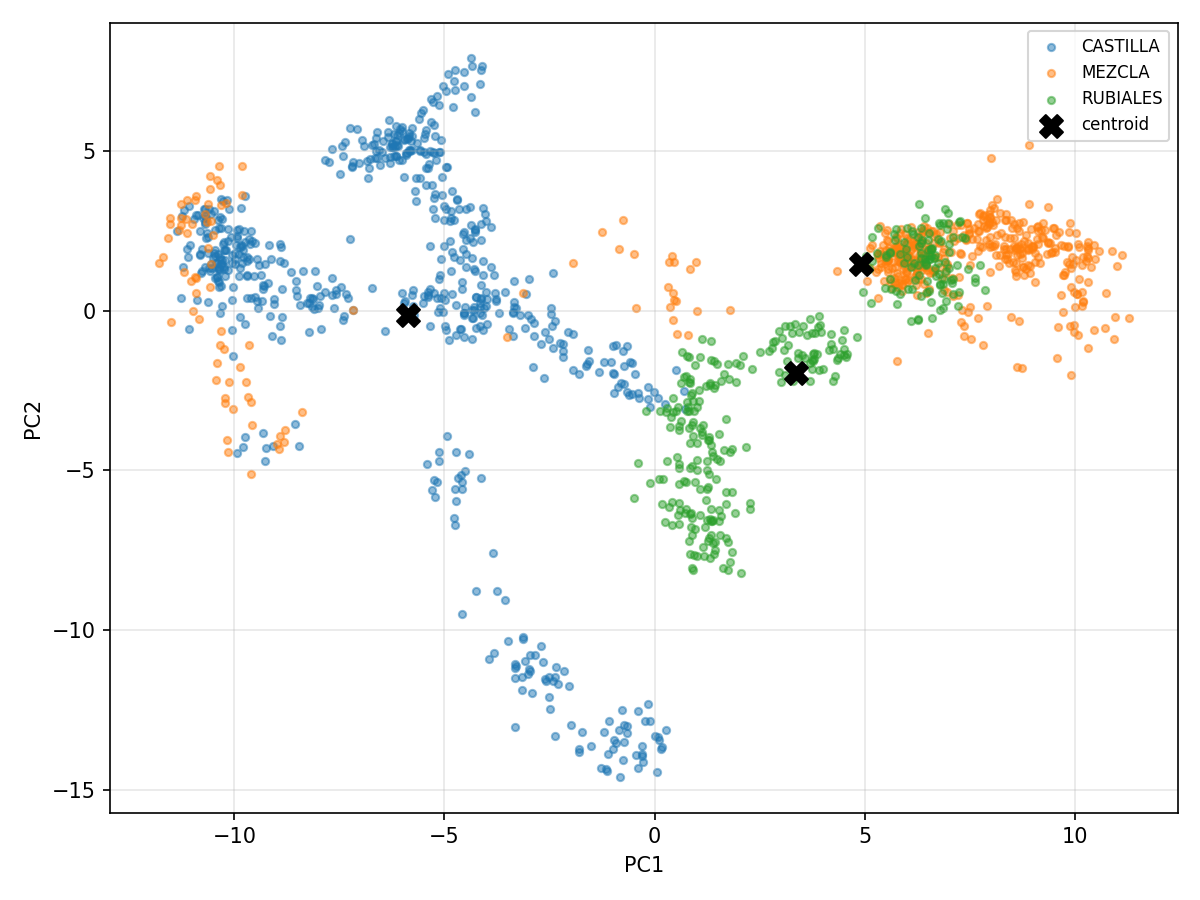

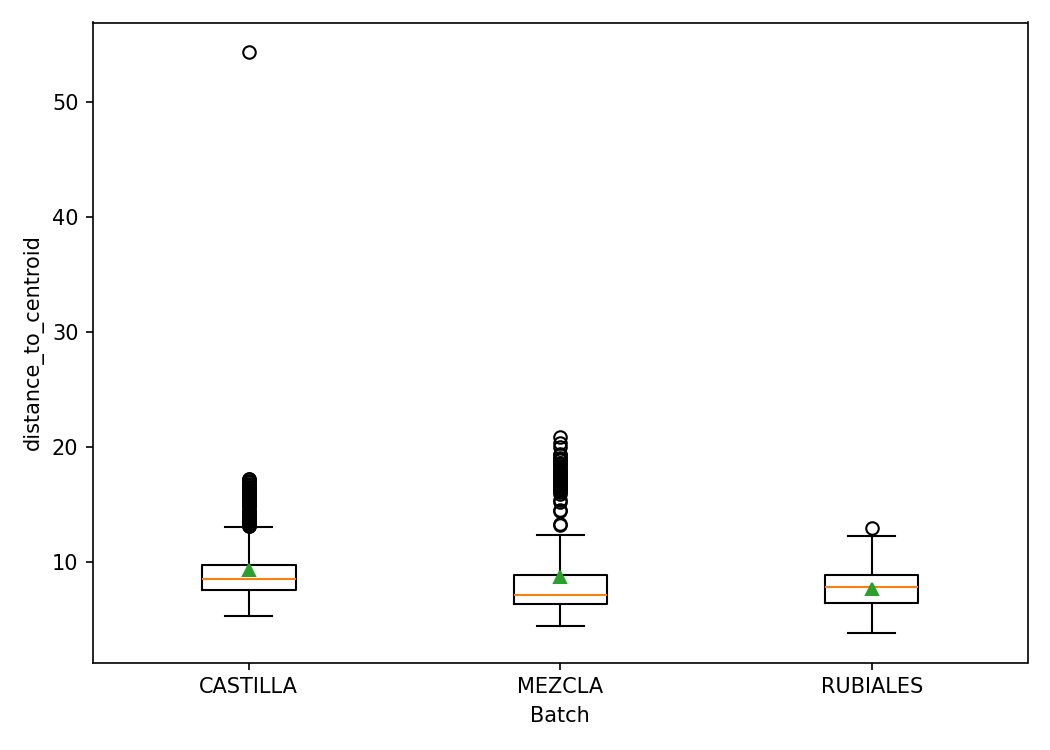

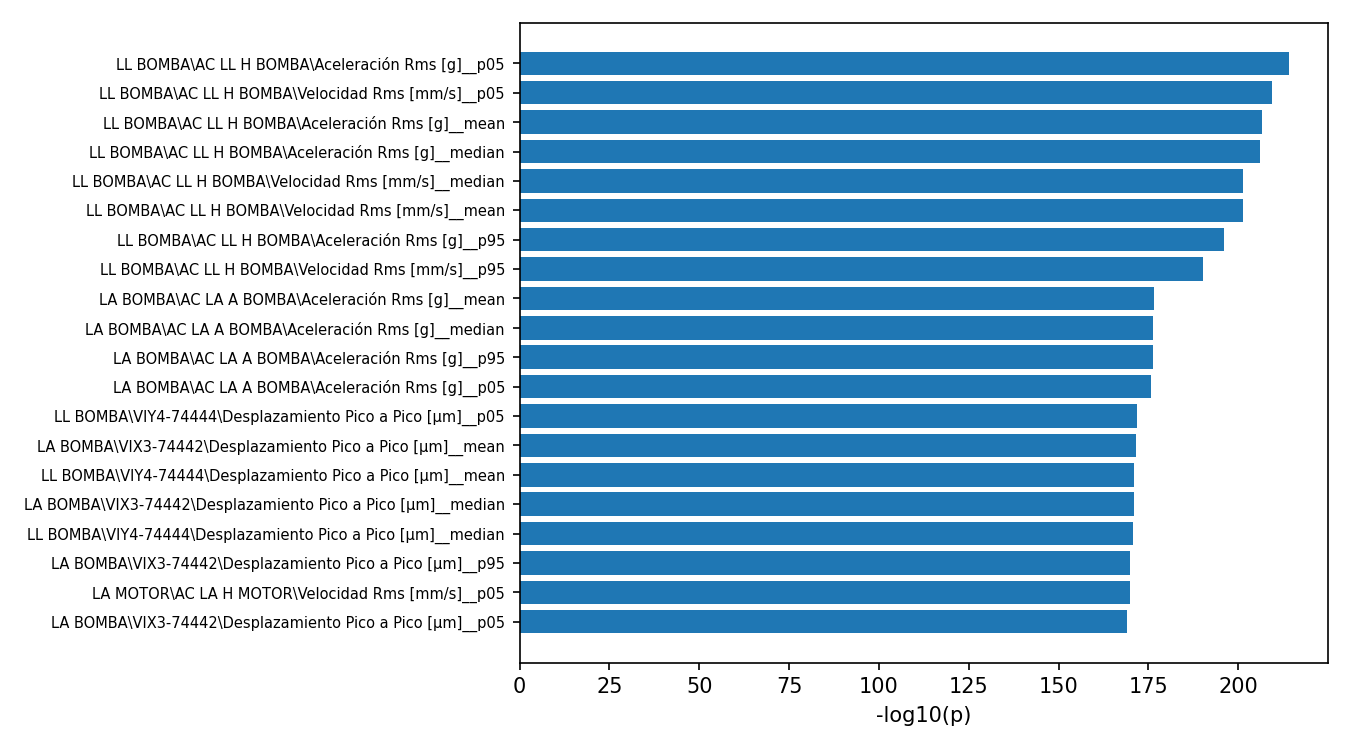

In [6]:
display_table(load_csv(OUTPUTS_TABLES / "statistical_validation_summary.csv"), 5)
display(Markdown("### Pairwise PERMANOVA (FDR)"))
display_table(load_csv(OUTPUTS_TABLES / "pairwise_permanova_fdr_results.csv"), 10)
display(Markdown("### Pairwise PERMDISP (FDR)"))
display_table(load_csv(OUTPUTS_TABLES / "pairwise_permdisp_fdr_results.csv"), 10)
display(Markdown("### Centroides PCA"))
display_table(load_csv(OUTPUTS_TABLES / "pca_centroids.csv"), 10)
display(Markdown("### Figuras"))
display_figure(OUTPUTS_FIGURES / "pca_batches.png")
display_figure(OUTPUTS_FIGURES / "permdisp_boxplot.png")
display_figure(OUTPUTS_FIGURES / "top_kruskal_features.png")


## 6. Modelado comparativo

Modelos comparados: **logistic_regression**, **svm_rbf**, **random_forest**, **xgboost**, **soft_voting_ensemble**.  
Validacion **temporal** con **StratifiedGroupKFold** por grupos (ver `cv_split_summary.csv`).

**Metricas:** F1 macro, balanced accuracy, MCC, Cohen Kappa (promedios CV en `dashboard_model_metrics.csv`).

**Hallazgos:** el modelo con mayor F1 macro en CV suele ser **XGBoost**; la ventaja frente a **soft_voting_ensemble** suele ser **marginal**. **No** usar `training_f1_macro` ni otras metricas del entrenamiento final sobre todas las ventanas como generalizacion.

,model_name,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,precision_macro_mean,recall_macro_mean,mcc_mean,cohen_kappa_mean
0,logistic_regression,0.930403,0.061625,0.926026,0.066143,0.927529,0.058189,0.942913,0.926026,0.898616,0.891121
1,random_forest,0.931432,0.087673,0.927373,0.099150,0.928430,0.090575,0.943291,0.927373,0.899394,0.892020
2,soft_voting_ensemble,0.936875,0.074118,0.934224,0.082398,0.935247,0.074371,0.948699,0.934224,0.907933,0.901031
3,svm_rbf,0.932800,0.082889,0.928518,0.093650,0.929943,0.085109,0.944816,0.928518,0.901509,0.894336
4,xgboost,0.937555,0.072658,0.934591,0.081599,0.935743,0.073318,0.948541,0.934591,0.908529,0.902134


### Matriz de confusion (mejor modelo, OOF agregado)

,true_label,pred_label,count,percent_by_true
0,CASTILLA,CASTILLA,603,98.368679
1,CASTILLA,MEZCLA,10,1.631321
2,MEZCLA,CASTILLA,40,7.936508
3,MEZCLA,MEZCLA,445,88.293651
4,MEZCLA,RUBIALES,19,3.769841
5,RUBIALES,CASTILLA,9,2.694611
6,RUBIALES,MEZCLA,14,4.191617
7,RUBIALES,RUBIALES,311,93.113772


,fold,n_train,n_test,n_train_groups,n_test_groups,train_classes,test_classes,train_group_overlap_with_test,class_coverage_warning
0,0,1157,294,39,10,"CASTILLA,MEZCLA,RUBIALES","CASTILLA,MEZCLA,RUBIALES",0,NaN
1,1,1154,297,39,10,"CASTILLA,MEZCLA,RUBIALES","CASTILLA,MEZCLA,RUBIALES",0,NaN
2,2,1157,294,39,10,"CASTILLA,MEZCLA,RUBIALES","CASTILLA,MEZCLA,RUBIALES",0,NaN
3,3,1155,296,39,10,"CASTILLA,MEZCLA,RUBIALES","CASTILLA,MEZCLA,RUBIALES",0,NaN
4,4,1181,270,40,9,"CASTILLA,MEZCLA,RUBIALES","CASTILLA,MEZCLA,RUBIALES",0,NaN


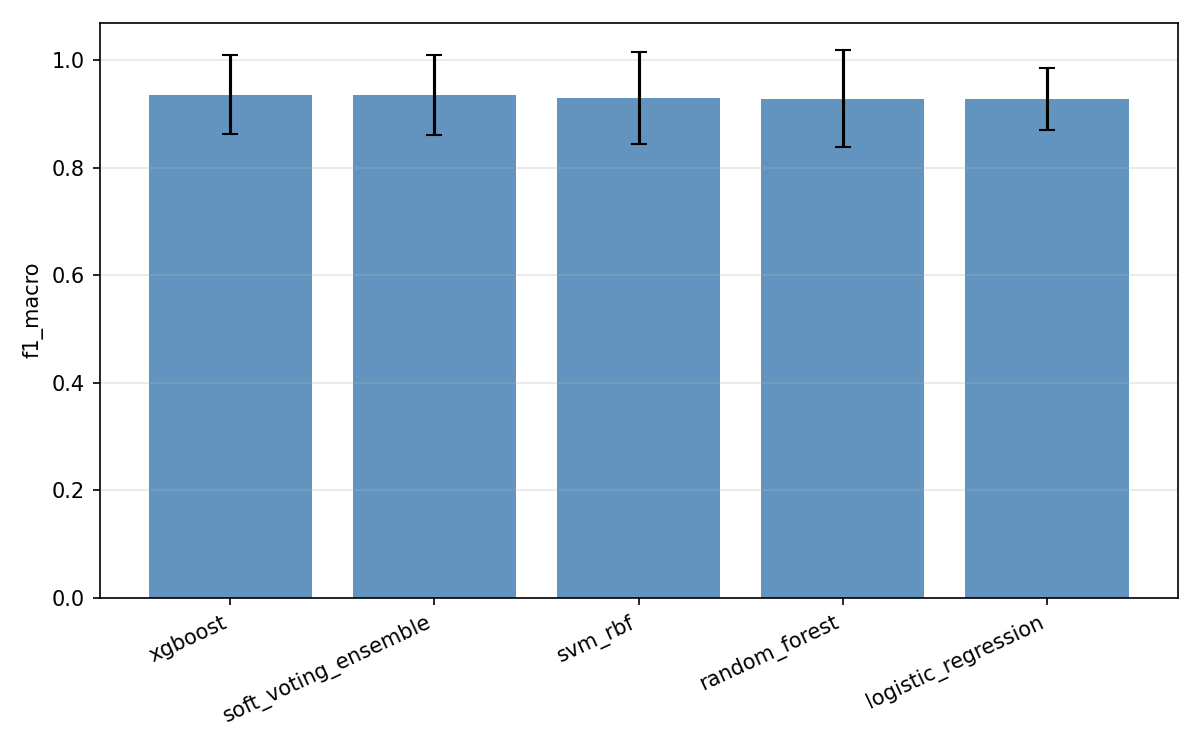

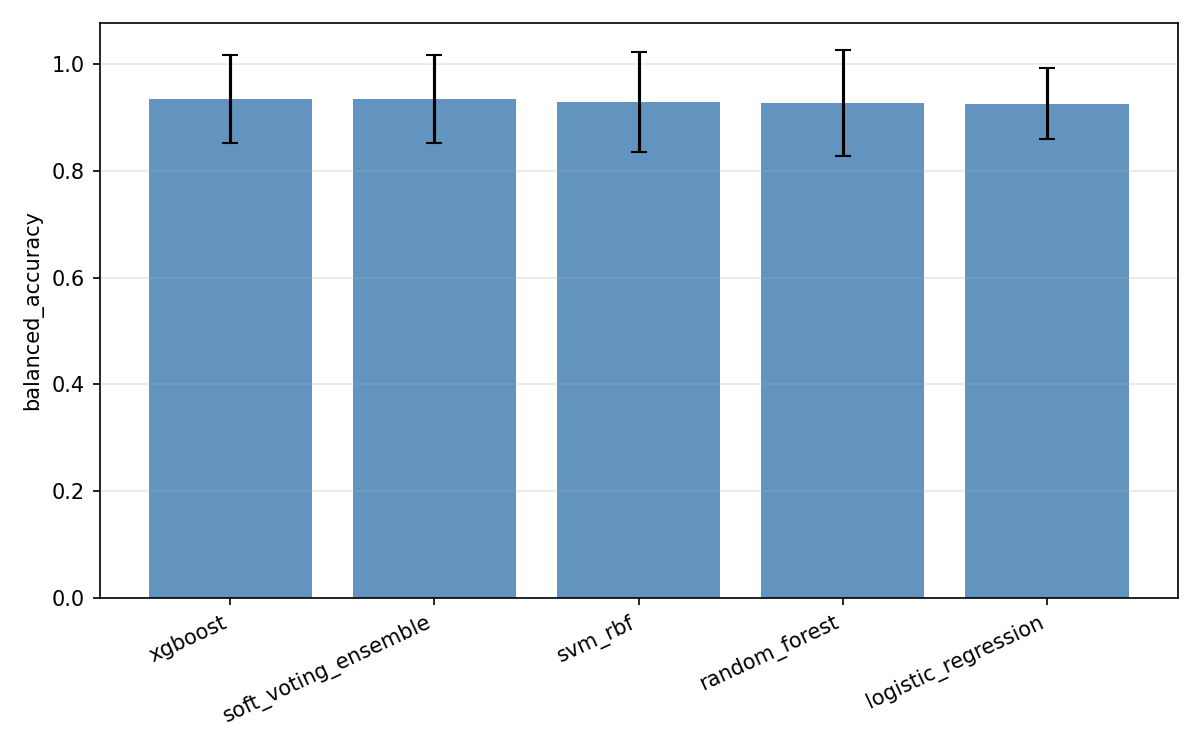

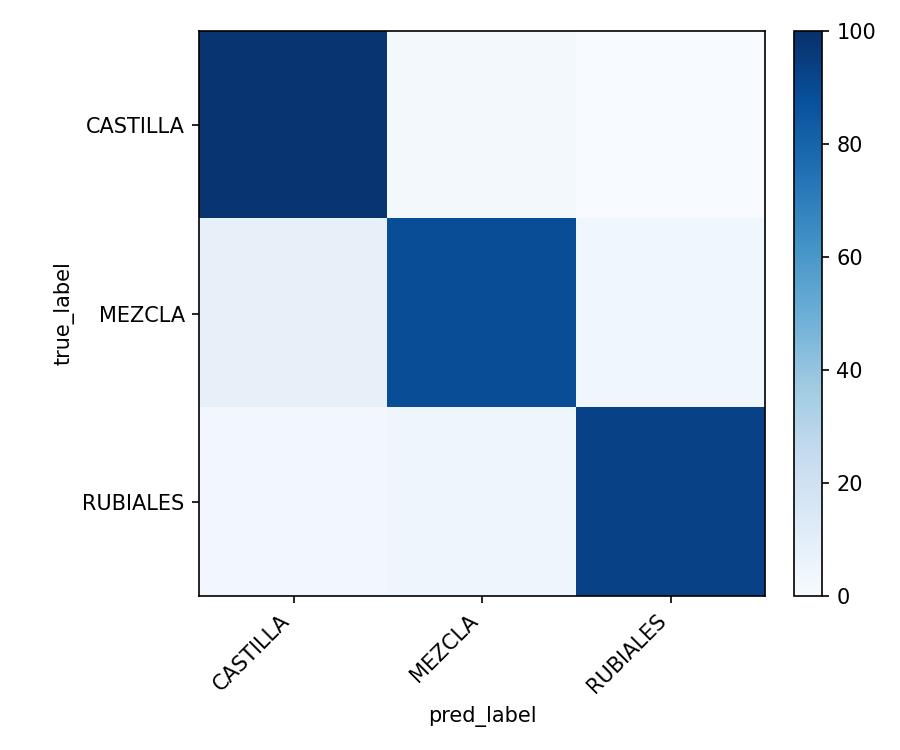

In [7]:
display_table(load_csv(DASHBOARD_DATA / "dashboard_model_metrics.csv"), 10)
display(Markdown("### Matriz de confusion (mejor modelo, OOF agregado)"))
display_table(load_csv(DASHBOARD_DATA / "dashboard_confusion_best_model.csv"), 15)
display_table(load_csv(OUTPUTS_TABLES / "cv_split_summary.csv", required=False), 20)
display_figure(OUTPUTS_FIGURES / "model_comparison_f1_macro.png")
display_figure(OUTPUTS_FIGURES / "model_comparison_balanced_accuracy.png")
display_figure(OUTPUTS_FIGURES / "confusion_matrix_best_model.png")


## 7. Modelo final

El modelo final (**XGBoost**) se entrena sobre las **1451** ventanas validas (sin transicion), con **120** features. Artefactos en `outputs/models/` (por ejemplo `model_final_xgboost.pkl`).

**Diferencia clave:** filas de `final_model_training_summary.csv` reflejan **ajuste en todo el conjunto de entrenamiento**; las metricas de **generalizacion** del notebook ejecutivo deben tomarse de **CV** (`dashboard_model_metrics.csv`).

In [8]:
display_table(load_csv(OUTPUTS_TABLES / "final_model_training_summary.csv"), 5)
display(Markdown("### Primeras filas de predicciones finales"))
display_table(load_csv(OUTPUTS_TABLES / "final_model_predictions.csv"), 12)
display(Markdown("**Advertencia:** `training_f1_macro = 1.0` (si aparece) es sobre entrenamiento completo, **no** es metrica de generalizacion."))


,n_training_windows,n_model_features,n_classes,training_accuracy,training_balanced_accuracy,training_f1_macro,training_precision_macro,training_recall_macro,training_mcc,training_cohen_kappa,mean_confidence,median_confidence,mean_margin_top2,median_margin_top2
0,1451,120,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.998602,0.999581,0.99737,0.999273


### Primeras filas de predicciones finales

,window_id,window_start,window_end,n_samples,Batch,label_majority_fraction,has_near_transition,y_true_label,y_pred_label,prob_CASTILLA,prob_MEZCLA,prob_RUBIALES,confidence,margin_top2,is_correct
0,0,2025-12-10 18:37:32,2025-12-10 18:38:31,60,RUBIALES,1.0,False,RUBIALES,RUBIALES,0.017816,0.000529,0.981655,0.981655,0.963839,True
1,1,2025-12-10 18:38:32,2025-12-10 18:39:31,60,RUBIALES,1.0,False,RUBIALES,RUBIALES,0.003206,0.000345,0.996449,0.996449,0.993243,True
2,2,2025-12-10 18:39:32,2025-12-10 18:40:31,60,RUBIALES,1.0,False,RUBIALES,RUBIALES,0.007945,0.000411,0.991644,0.991644,0.983699,True
3,3,2025-12-10 18:40:32,2025-12-10 18:41:31,60,RUBIALES,1.0,False,RUBIALES,RUBIALES,0.010521,0.000359,0.989120,0.989120,0.978598,True
4,4,2025-12-10 18:41:32,2025-12-10 18:42:31,60,RUBIALES,1.0,False,RUBIALES,RUBIALES,0.003228,0.000550,0.996222,0.996222,0.992994,True
5,5,2025-12-10 18:42:32,2025-12-10 18:43:31,60,RUBIALES,1.0,False,RUBIALES,RUBIALES,0.004027,0.001148,0.994825,0.994825,0.990799,True
6,6,2025-12-10 18:43:32,2025-12-10 18:44:31,60,RUBIALES,1.0,False,RUBIALES,RUBIALES,0.011431,0.000305,0.988264,0.988264,0.976833,True
7,7,2025-12-10 18:44:32,2025-12-10 18:45:31,60,RUBIALES,1.0,False,RUBIALES,RUBIALES,0.005556,0.000518,0.993926,0.993926,0.988371,True
8,8,2025-12-10 18:45:32,2025-12-10 18:46:31,60,RUBIALES,1.0,False,RUBIALES,RUBIALES,0.003205,0.000269,0.996526,0.996526,0.993321,True
9,12,2025-12-10 18:49:32,2025-12-10 18:50:31,60,CASTILLA,1.0,False,CASTILLA,CASTILLA,0.979784,0.001164,0.019052,0.979784,0.960732,True


**Advertencia:** `training_f1_macro = 1.0` (si aparece) es sobre entrenamiento completo, **no** es metrica de generalizacion.

## 8. Interpretabilidad del modelo

- **Permutation importance** y **SHAP** global ayudan a explicar **contribuciones al modelo**; **no** demuestran causalidad ni mecanismo fisico.
- Rankings agregados por **componente**, **familia**, **posicion** y **estadistico**.

**Lectura tipica:** componente **bomba** suele liderar importancia agregada, seguido de cerca por **motor**; familia **acceleration_rms** suele ser la mas relevante. La mejor feature consolidada aparece en `interpretability_summary.csv` (`best_feature_consolidated`).

,n_windows_used,n_model_features,n_classes,best_feature_consolidated,best_feature_raw_variable,top_raw_variable,top_component,top_family,top_position,top_statistic,permutation_n_repeats,shap_max_samples,shap_status,shap_warning
0,1451,120,3,LA BOMBA\AC LA A BOMBA\Aceleración Rms [g]__mean,LA BOMBA\AC LA A BOMBA\Aceleración Rms [g],LA MOTOR\AC LA H MOTOR\Aceleración Rms [g],bomba,acceleration_rms,la,p95,10,1000,ok,beeswarm_multiclase_alternativa_barras_top20


### Top 20 features (consolidated_score)

,consolidated_rank,feature,raw_variable,statistic,family,component,position,unit,perm_importance_mean,shap_importance_mean_abs,consolidated_score
0,1,LA BOMBA\AC LA A BOMBA\Aceleración Rms [g]__mean,LA BOMBA\AC LA A BOMBA\Aceleración Rms [g],mean,acceleration_rms,bomba,la,g,0.002739,1.082835,0.991597
1,2,LA BOMBA\AC LA A BOMBA\Aceleración Rms [g]__me...,LA BOMBA\AC LA A BOMBA\Aceleración Rms [g],median,acceleration_rms,bomba,la,g,0.000000,0.643174,0.983193
2,3,LA MOTOR\AC LA H MOTOR\Velocidad Rms [mm/s]__p95,LA MOTOR\AC LA H MOTOR\Velocidad Rms [mm/s],p95,velocity_rms,motor,la,mm/s,0.000000,0.480970,0.978992
3,4,LA BOMBA\AC LA A BOMBA\Velocidad Rms [mm/s]__p95,LA BOMBA\AC LA A BOMBA\Velocidad Rms [mm/s],p95,velocity_rms,bomba,la,mm/s,0.022492,0.159372,0.974790
4,5,LL BOMBA\AC LL H BOMBA\Aceleración Rms [g]__p95,LL BOMBA\AC LL H BOMBA\Aceleración Rms [g],p95,acceleration_rms,bomba,ll,g,0.000000,0.226329,0.974790
5,6,LA BOMBA\AC LA A BOMBA\Aceleración Rms [g]__p95,LA BOMBA\AC LA A BOMBA\Aceleración Rms [g],p95,acceleration_rms,bomba,la,g,0.000000,0.187253,0.970588
6,7,LA BOMBA\AC LA A BOMBA\Aceleración Rms [g]__p05,LA BOMBA\AC LA A BOMBA\Aceleración Rms [g],p05,acceleration_rms,bomba,la,g,0.000000,0.163886,0.966387
7,8,LL MOTOR\AC LL H MOTOR\Aceleración Rms [g]__p95,LL MOTOR\AC LL H MOTOR\Aceleración Rms [g],p95,acceleration_rms,motor,ll,g,0.000000,0.140013,0.957983
8,9,LA BOMBA\AC LA H BOMBA\Velocidad Rms [mm/s]__p95,LA BOMBA\AC LA H BOMBA\Velocidad Rms [mm/s],p95,velocity_rms,bomba,la,mm/s,0.000000,0.138849,0.953782
9,10,LA MOTOR\AC LA H MOTOR\Aceleración Rms [g]__p95,LA MOTOR\AC LA H MOTOR\Aceleración Rms [g],p95,acceleration_rms,motor,la,g,0.000000,0.132055,0.949580


### Rank componente

,component,importance_sum,importance_mean,n_features,share_percent
0,bomba,38.033613,0.760672,50,42.949326
1,motor,36.697479,0.733950,50,41.440501
2,variador,13.823529,0.691176,20,15.610173


...

,family,importance_sum,importance_mean,n_features,share_percent
0,acceleration_rms,32.117647,0.802941,40,36.268742
1,displacement_pp,28.844538,0.721113,40,32.572594
2,velocity_rms,27.592437,0.689811,40,31.158664


### Rank posicion

,position,importance_sum,importance_mean,n_features,share_percent
0,la,44.642857,0.744048,60,50.412792
1,ll,30.088235,0.752206,40,33.977035
2,lm,6.957983,0.695798,10,7.857278
3,lb,6.865546,0.686555,10,7.752894


### Rank estadistico

,statistic,importance_sum,importance_mean,n_features,share_percent
0,p95,18.907563,0.787815,24,21.351300
1,mean,18.588235,0.774510,24,20.990700
2,median,17.907563,0.746148,24,20.222054
3,p05,17.436975,0.726541,24,19.690643
4,iqr,15.714286,0.654762,24,17.745303


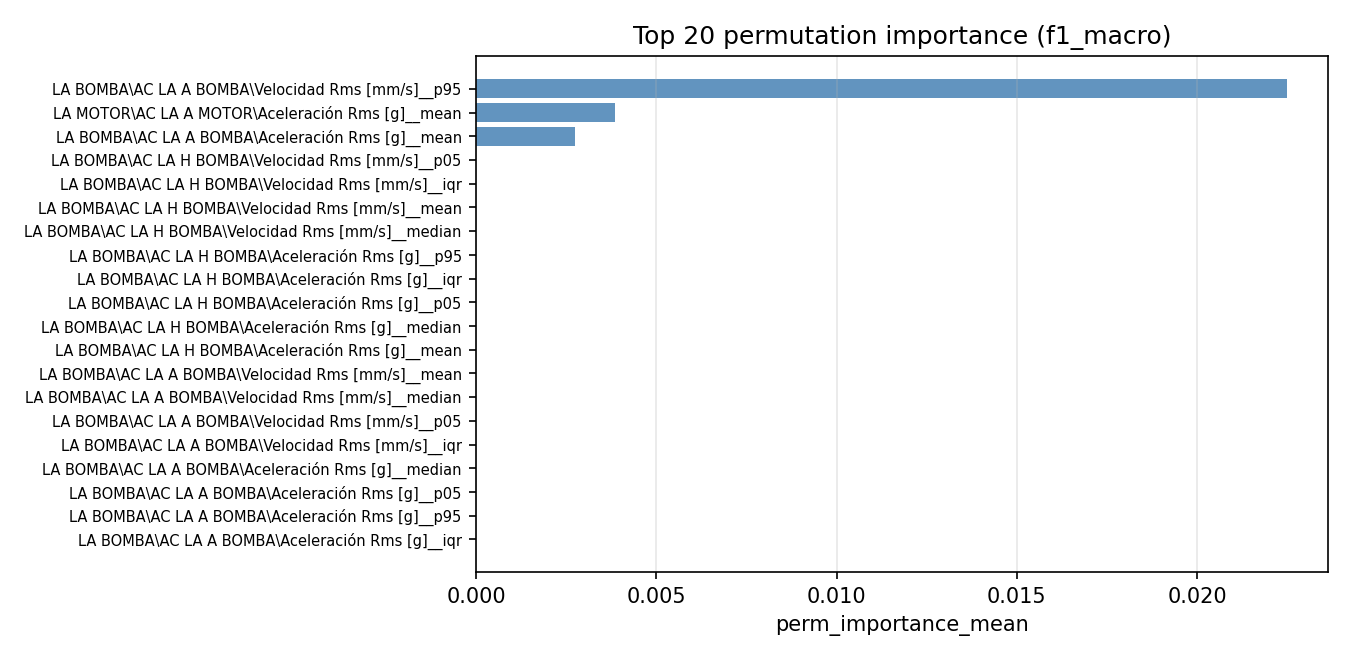

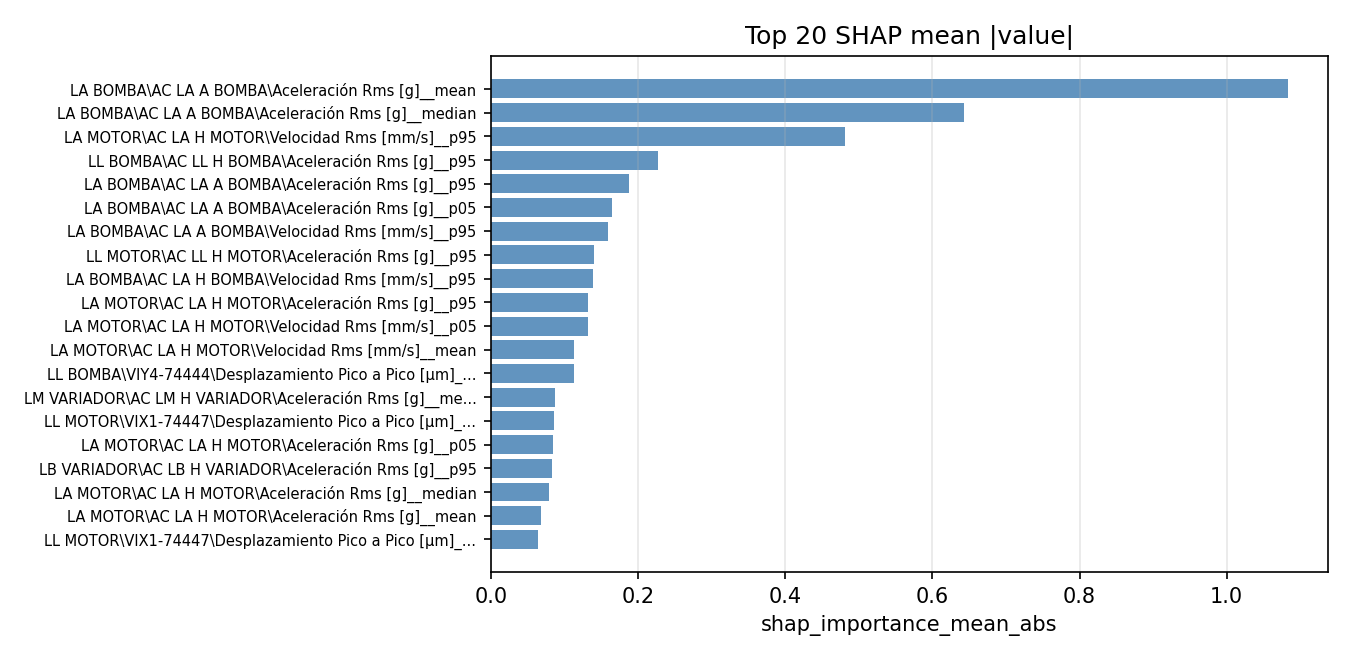

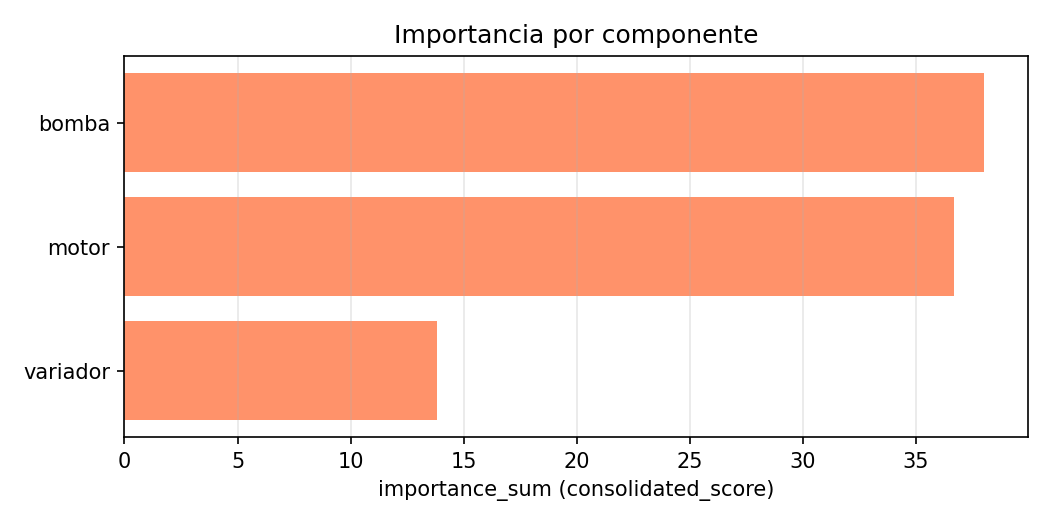

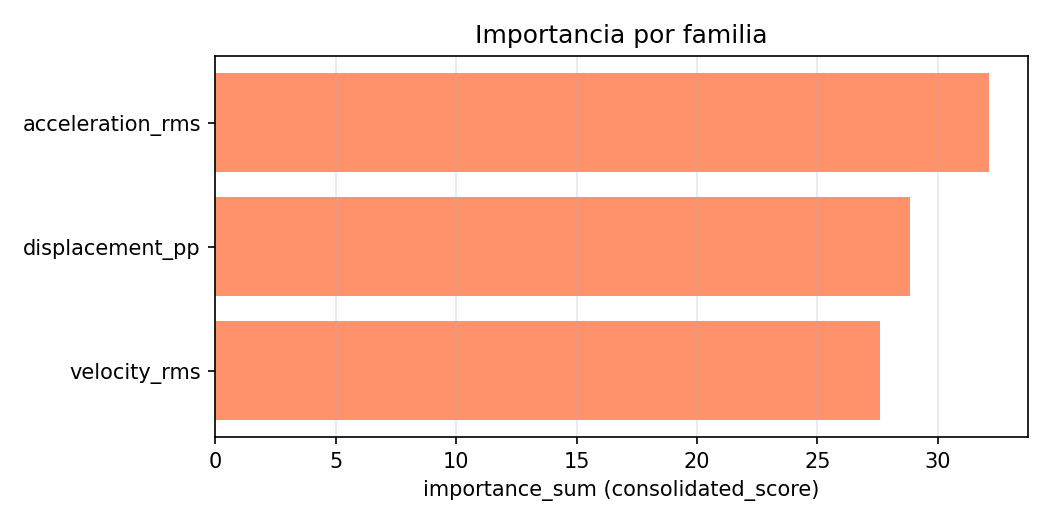

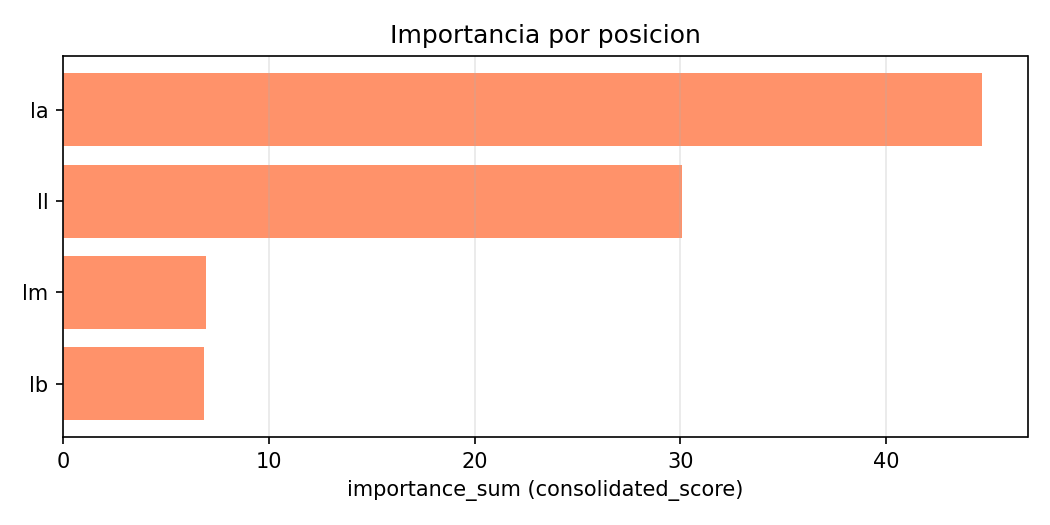

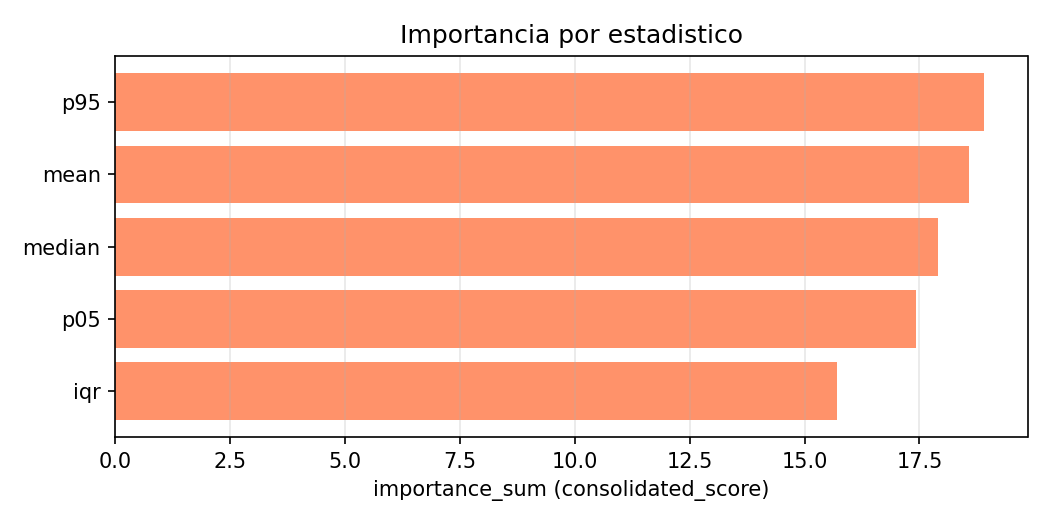

In [9]:
display_table(load_csv(OUTPUTS_TABLES / "interpretability_summary.csv"), 5)
fi = load_csv(DASHBOARD_DATA / "dashboard_feature_importance.csv")
if not fi.empty and "consolidated_score" in fi.columns:
    display(Markdown("### Top 20 features (consolidated_score)"))
    display_table(fi.sort_values("consolidated_score", ascending=False).head(20), 20)
for name, title in [
    ("dashboard_rank_component.csv", "Rank componente"),
    ("dashboard_rank_family.csv", "Rank familia"),
    ("dashboard_rank_position.csv", "Rank posicion"),
    ("dashboard_rank_statistic.csv", "Rank estadistico"),
]:
    display(Markdown(f"### {title}"))
    display_table(load_csv(DASHBOARD_DATA / name), 15)
display_figure(OUTPUTS_FIGURES / "top_20_permutation_importance.png")
display_figure(OUTPUTS_FIGURES / "top_20_shap_importance.png")
display_figure(OUTPUTS_FIGURES / "importance_by_component.png")
display_figure(OUTPUTS_FIGURES / "importance_by_family.png")
display_figure(OUTPUTS_FIGURES / "importance_by_position.png")
display_figure(OUTPUTS_FIGURES / "importance_by_statistic.png")


## 9. Pesos ponderados y assessment de condicion

Los **pesos ponderados** definen un **indice de condicion del activo** (umbrales / percentiles), **no** la importancia ML de las variables en el clasificador.

Se esperan **24/24** variables mapeadas (ver `assessment_summary.csv`). Con **H, HH y V0** vacios en el Excel, el metodo dominante es **robust_percentile_fallback**.

El indice es **exploratorio y comparativo** entre ventanas/batches; **no** es diagnostico normativo de falla.

,n_weight_rows,n_weights_mapped,n_weights_unmatched,n_duplicate_matches,normalized_weight_sum,n_windows_scored,median_available_weight,top_weighted_variable,top_weighted_component,top_weighted_family,assessment_method
0,24,24,0,0,1.0,1466,1.0,Aceleración RMS — LA Bomba Axial [g],bomba,acceleration_rms,robust_percentile_fallback


,Batch,n_windows,condition_index_mean,condition_index_median,condition_index_p05,condition_index_p95,condition_index_min,condition_index_max
0,CASTILLA,619,20.779234,21.564193,15.008239,25.649717,7.679662,27.587736
1,MEZCLA,508,30.446017,32.879134,11.558008,36.485553,7.109007,38.901378
2,RUBIALES,339,28.624178,27.773278,24.170271,34.248112,22.568351,36.867656


,weight_variable,matched_raw_column,component,family,position,weight_raw,weight_normalized,share_percent
0,Aceleración RMS — LA Bomba Axial [g],LA BOMBA\AC LA A BOMBA\Aceleración Rms [g],bomba,acceleration_rms,la,4.8,0.060150,6.015038
1,Aceleración RMS — LA Bomba Horizontal [g],LA BOMBA\AC LA H BOMBA\Aceleración Rms [g],bomba,acceleration_rms,la,4.8,0.060150,6.015038
2,Desplazamiento Pico a Pico VIY3 — LA Bomba [µm],LA BOMBA\VIY3-74441\Desplazamiento Pico a Pico...,bomba,displacement_pp,la,4.0,0.050125,5.012531
3,Desplazamiento Pico a Pico VIX3 — LA Bomba [µm],LA BOMBA\VIX3-74442\Desplazamiento Pico a Pico...,bomba,displacement_pp,la,4.0,0.050125,5.012531
4,Aceleración RMS — LA Motor Axial [g],LA MOTOR\AC LA A MOTOR\Aceleración Rms [g],motor,acceleration_rms,la,3.8,0.047619,4.761905
5,Aceleración RMS — LA Motor Horizontal [g],LA MOTOR\AC LA H MOTOR\Aceleración Rms [g],motor,acceleration_rms,la,3.8,0.047619,4.761905
6,Velocidad RMS — LA Bomba Horizontal [mm/s],LA BOMBA\AC LA H BOMBA\Velocidad Rms [mm/s],bomba,velocity_rms,la,3.8,0.047619,4.761905
7,Velocidad RMS — LA Bomba Axial [mm/s],LA BOMBA\AC LA A BOMBA\Velocidad Rms [mm/s],bomba,velocity_rms,la,3.8,0.047619,4.761905
8,Aceleración RMS — LL Bomba Horizontal [g],LL BOMBA\AC LL H BOMBA\Aceleración Rms [g],bomba,acceleration_rms,ll,3.8,0.047619,4.761905
9,Aceleración RMS — LL Motor Horizontal [g],LL MOTOR\AC LL H MOTOR\Aceleración Rms [g],motor,acceleration_rms,ll,3.2,0.040100,4.010025


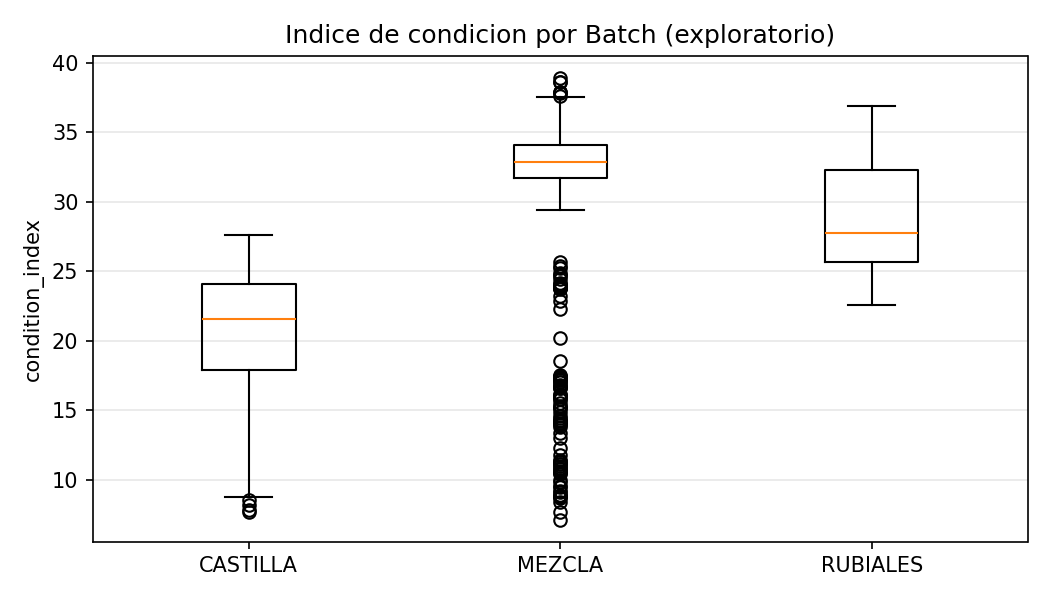

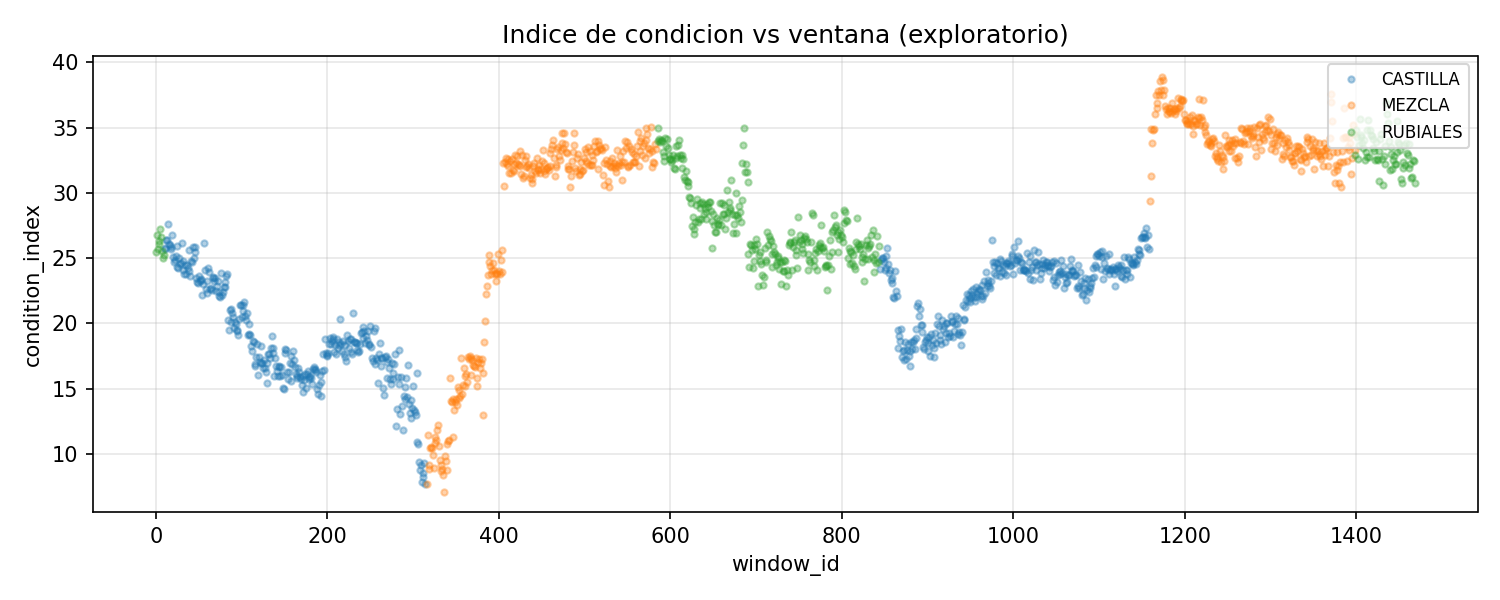

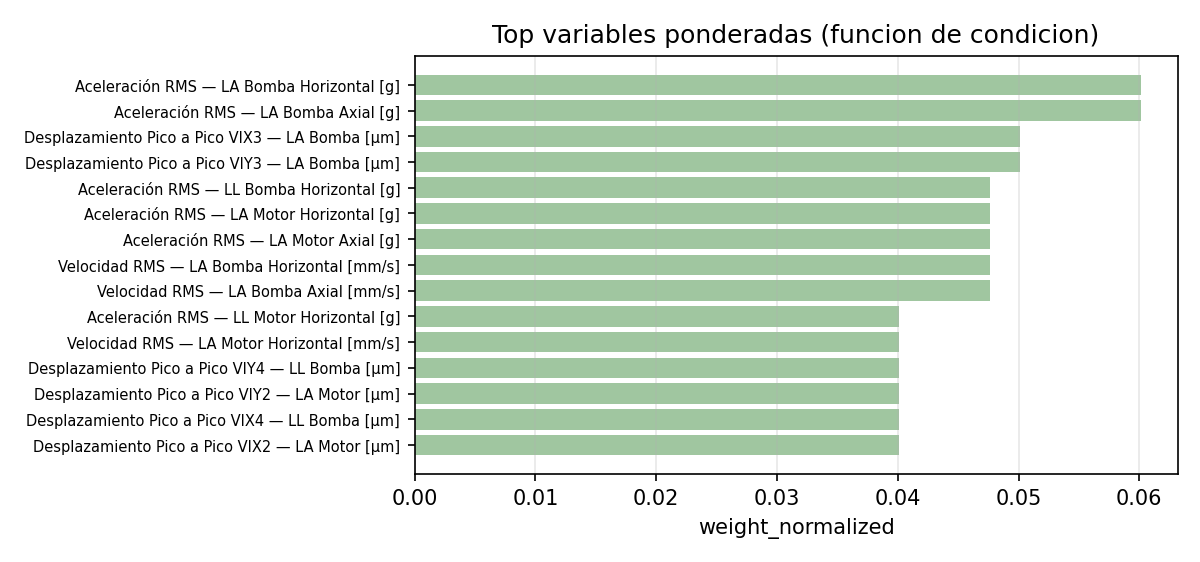

In [10]:
display_table(load_csv(OUTPUTS_TABLES / "assessment_summary.csv"), 5)
display_table(load_csv(DASHBOARD_DATA / "dashboard_condition_index_by_batch.csv"), 10)
display_table(load_csv(DASHBOARD_DATA / "dashboard_top_weighted_variables.csv"), 25)
display_figure(OUTPUTS_FIGURES / "condition_index_by_batch.png")
display_figure(OUTPUTS_FIGURES / "condition_index_time_series.png")
display_figure(OUTPUTS_FIGURES / "top_weighted_variables.png")


## 10. Dashboard

Aplicacion **Dash** en `dashboard/app.py`: lee **solo** CSV de `data/dashboard/`, **no** reentrena modelos ni recalcula pipeline. **Siete pestanas:** resumen ejecutivo; desempeno del modelo; predicciones por ventana; validacion estadistica; interpretabilidad; assessment ponderado; datos y advertencias.

**Comandos:**
```text
python run_pipeline.py --stage dashboard_exports
python dashboard/app.py
```
Luego abrir `http://127.0.0.1:8050`.

In [11]:
readme = DASHBOARD_DATA / "README_dashboard_data.md"
if readme.is_file():
    txt = readme.read_text(encoding="utf-8")
    display(Markdown("### Extracto `README_dashboard_data.md`"))
    display(Markdown(txt[:2500] + ("\n\n..." if len(txt) > 2500 else "")))
else:
    display(Markdown("_README no encontrado._"))


### Extracto `README_dashboard_data.md`

# Datos derivados para dashboard (Proyecto 4 BPC)

## Origen

Los archivos CSV en esta carpeta son **derivados**: se generan leyendo `outputs/tables/` y
`data/processed/` **sin** recalcular features, modelos, SHAP, estadistica inferencial ni assessment.

## Uso

No editar manualmente estos archivos en entornos productivos.

Regenerar tras actualizar etapas previas:

```text
python run_pipeline.py --stage dashboard_exports
```

## Archivos

| Archivo | Contenido breve |
|---------|-----------------|
| dashboard_kpis.csv | KPIs consolidados (metric, value, category, description) |
| dashboard_model_metrics.csv | Metricas CV por modelo (filas = modelos) |
| dashboard_confusion_best_model.csv | Matriz de confusion del mejor modelo |
| dashboard_predictions.csv | Predicciones finales + indice de condicion por ventana |
| dashboard_feature_importance.csv | Ranking consolidado de features (interpretabilidad) |
| dashboard_rank_*.csv | Rankings agregados por variable, componente, familia, posicion, estadistico |
| dashboard_top_weighted_variables.csv | Variables con mayor peso en assessment |
| dashboard_condition_index_by_batch.csv | Indice de condicion resumido por Batch |
| dashboard_pairwise_permanova.csv | Comparaciones pairwise PERMANOVA (FDR) |
| dashboard_pairwise_permdisp.csv | Comparaciones pairwise PERMDISP (FDR) |
| dashboard_pca_centroids.csv | Centroides PCA por clase |
| dashboard_batch_transitions.csv | Transiciones de operacion entre batches |

## Advertencias

- Las metricas de **generalizacion** relevantes para comparar modelos son las de **validacion cruzada**
  (`dashboard_model_metrics.csv`), no las de entrenamiento del modelo final (pueden ser optimistas).
- El **assessment** de condicion usa en este proyecto principalmente `robust_percentile_fallback`
  cuando los umbrales H, HH y V0 del Excel de pesos estan vacios.
- Los **pesos ponderados** del activo **no** representan importancia ML ni causalidad.
- **SHAP** y permutation importance **no** implican causalidad.
- **MEZCLA** se trata como clase operacional independiente (no es solo transicion).


## 11. Limitaciones

- Campana de **~24 h** de datos; resultados dependen de esa ventana operativa.
- **Sin variables de proceso** (presion, caudal, densidad, temperatura).
- **No** implementar en **control real** sin revision tecnica y pruebas en planta.
- **MEZCLA** no tiene composicion quimica explicita en el dataset.
- **Assessment** no usa umbrales completos **H, HH, V0** en el Excel → **fallback** de percentiles.
- **SHAP** / permutation importance **no** prueban causalidad.

## 12. Conclusiones y recomendaciones

- La **firma vibratoria** permite clasificar el **Batch** con buen desempeno en CV; **XGBoost** es el modelo seleccionado en la comparativa.
- Las clases son **estadisticamente diferenciables** (PERMANOVA) y hay senales de **dispersion interna distinta** (PERMDISP).
- **Recomendaciones:** lineas base **diferenciadas por batch**; completar **H, HH y V0** para un assessment mas normativo; validar con **mas dias/campanas** antes de uso operacional real.

## Checklist de reproducibilidad

Tabla generada en la siguiente celda: existencia de archivos clave y conteos esperados (sin ejecutar pipeline desde el notebook).

In [12]:
def _exists(rel: Path) -> bool:
    return rel.is_file()

def _rows(rel: Path) -> int:
    return len(pd.read_csv(rel)) if rel.is_file() else -1

chk = [
    ("data/dashboard/dashboard_kpis.csv", _exists(DASHBOARD_DATA / "dashboard_kpis.csv"), ""),
    ("data/processed/bpc_windowed_features.csv", _exists(DATA_PROCESSED / "bpc_windowed_features.csv"), ""),
    ("outputs/models/model_final_xgboost.pkl", _exists(OUTPUTS_MODELS / "model_final_xgboost.pkl"), ""),
    ("dashboard/app.py", _exists(PROJECT_ROOT / "dashboard" / "app.py"), ""),
    ("data/dashboard/dashboard_predictions.csv (1451 filas)", _rows(DASHBOARD_DATA / "dashboard_predictions.csv") == 1451, f"n={_rows(DASHBOARD_DATA / 'dashboard_predictions.csv')}"),
    ("data/dashboard/dashboard_feature_importance.csv (120)", _rows(DASHBOARD_DATA / "dashboard_feature_importance.csv") == 120, f"n={_rows(DASHBOARD_DATA / 'dashboard_feature_importance.csv')}"),
    ("data/dashboard/dashboard_model_metrics.csv (5 modelos)", _rows(DASHBOARD_DATA / "dashboard_model_metrics.csv") == 5, f"n={_rows(DASHBOARD_DATA / 'dashboard_model_metrics.csv')}"),
    ("data/dashboard/dashboard_condition_index_by_batch.csv (3)", _rows(DASHBOARD_DATA / "dashboard_condition_index_by_batch.csv") == 3, f"n={_rows(DASHBOARD_DATA / 'dashboard_condition_index_by_batch.csv')}"),
]
df_chk = pd.DataFrame(chk, columns=["item", "ok", "nota"])
display(df_chk)


,item,ok,nota
0,data/dashboard/dashboard_kpis.csv,True,
1,data/processed/bpc_windowed_features.csv,True,
2,outputs/models/model_final_xgboost.pkl,True,
3,dashboard/app.py,True,
4,data/dashboard/dashboard_predictions.csv (1451...,True,n=1451
5,data/dashboard/dashboard_feature_importance.cs...,True,n=120
6,data/dashboard/dashboard_model_metrics.csv (5 ...,True,n=5
7,data/dashboard/dashboard_condition_index_by_ba...,True,n=3
